In [ ]:
from pathlib import Path

from IPython.display import Image, Markdown, display



STATIC_IMAGE_DIR = Path("/kaggle/input/notebook-static-images-public")

display(Markdown("## Saved analysis figures"))

for image_path in sorted(STATIC_IMAGE_DIR.glob("perturbations-*.png")):

    display(Markdown(f"**{image_path.stem}**"))

    display(Image(filename=str(image_path)))

In [14]:
import pandas as pd
import anndata as ad
import scipy.sparse as sp

base = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline"

obs = pd.read_csv(f"{base}/multiome_obs_meta.csv")
var = pd.read_csv(f"{base}/multiome_var_meta.csv")
X = pd.read_parquet(f"{base}/multiome_train.parquet")

obs.index = obs.index.astype(str)

cell_map = pd.Series(
    range(len(obs)),
    index=obs["obs_id"]
)

var.index = var["location"].astype(str)

feature_map = pd.Series(
    range(len(var)),
    index=var["location"]
)

rows = cell_map.loc[X["obs_id"]].values
cols = feature_map.loc[X["location"]].values
values = X["normalized_count"].values

matrix = sp.coo_matrix(
    (values, (rows, cols)),
    shape=(len(obs), len(var))
).tocsr()

adata = ad.AnnData(
    X=matrix,
    obs=obs,
    var=var
)

print(adata)

AnnData object with n_obs × n_vars = 25551 × 158205
    obs: 'obs_id', 'cell_type', 'donor_id'
    var: 'location', 'gene_id', 'feature_type', 'genome', 'interval'


In [17]:
save_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/multiome_adata.h5ad"

adata.write_h5ad(
    save_path,
    compression="gzip")

In [19]:
adata.obs

,obs_id,cell_type,donor_id
0,000225c1151ab841,B cells,donor_0
1,0003c40a54367871,T cells CD4+,donor_2
2,0004bf574b822c3c,T cells CD4+,donor_2
3,000d59b5478f28e2,B cells,donor_0
4,0011b7473923d7b5,NK cells,donor_2
...,...,...,...
25546,fff2ca1f64c10339,T cells CD4+,donor_0
25547,fff87e64f509b570,T cells CD4+,donor_0
25548,fff9778b31bc2539,Myeloid cells,donor_2
25549,fffa92f71d2440de,NK cells,donor_1


In [23]:
import pandas as pd

de_train = pd.read_parquet("/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/de_train.parquet")

In [27]:
de_train[de_train['cell_type'] == 'B cells']

,cell_type,sm_name,sm_lincs_id,SMILES,control,A1BG,A1BG-AS1,A2M,A2M-AS1,A2MP1,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1
8,B cells,Idelalisib,LSM-1205,CC[C@H](Nc1ncnc2[nH]cnc12)c1nc2cccc(F)c2c(=O)n...,False,0.394173,-0.153824,0.178232,0.566241,0.391377,...,-1.052302,-1.176587,-1.220291,-0.278944,-0.095066,1.101790,0.061803,1.406335,-0.264996,-0.119743
30,B cells,Crizotinib,LSM-1027,C[C@@H](Oc1cc(-c2cnn(C3CCNCC3)c2)cnc1N)c1c(Cl)...,False,-0.221234,-0.588647,0.021279,1.104213,1.584397,...,-0.363383,0.215196,1.177265,0.832644,0.296236,0.603842,1.152725,0.599055,0.253165,0.762857
72,B cells,Linagliptin,LSM-45916,CC#CCn1c(N2CCC[C@@H](N)C2)nc2c1c(=O)n(Cc1nc(C)...,False,-0.096688,0.057827,0.261704,0.054919,1.010873,...,-0.130766,-0.990278,-1.384846,0.742082,-0.349105,-0.091224,-0.721902,-0.098806,-1.570230,-0.013876
94,B cells,Palbociclib,LSM-1071,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n(C2C...,False,-0.486782,-0.218410,0.611861,0.621570,0.430577,...,-0.215501,0.118039,-0.265851,-0.161122,0.651592,0.206849,1.810892,-0.288101,-0.175212,-0.046565
104,B cells,Dabrafenib,LSM-6303,CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2...,True,0.942197,0.539713,-0.417087,0.391397,2.049071,...,-0.094318,-0.043478,-0.269027,0.484859,0.905045,0.277953,1.126481,0.432023,-2.508760,-0.354758
141,B cells,Alvocidib,LSM-1011,CN1CC[C@H](c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)oc...,False,5.973634,1.339989,7.261231,8.021802,24.671829,...,-0.424277,2.548691,1.733338,6.723045,6.636466,2.895881,2.974078,-0.076024,1.453228,-0.159255
154,B cells,LDN 193189,LSM-1115,c1ccc2c(-c3cnn4cc(-c5ccc(N6CCNCC6)cc5)cnc34)cc...,False,0.555620,-0.138248,-0.153085,-0.325607,-0.031991,...,-0.529852,0.328504,-0.144491,0.360194,0.064081,-0.675370,0.379266,0.121937,-0.920557,-0.249233
168,B cells,R428,LSM-45574,Nc1nc(Nc2ccc3c(c2)CC[C@@H](N2CCCC2)CC3)nn1-c1c...,False,0.131392,-0.085207,-0.309031,-0.409487,0.042451,...,-0.464015,-0.027599,-2.321876,-0.296499,-0.340603,-0.520751,0.043362,-0.004477,-0.640411,0.304981
233,B cells,Porcn Inhibitor III,LSM-47425,O=C(CSc1nc2c(c(=O)n1-c1ccccc1)SCC2)Nc1ccc(-c2c...,False,0.161235,0.480509,-0.181097,0.130730,-0.489882,...,0.659575,-0.087127,-0.141743,0.084044,-2.601160,0.027574,-0.083122,0.484980,-0.740650,0.272056
275,B cells,Belinostat,LSM-43181,O=C(/C=C/c1cccc(S(=O)(=O)Nc2ccccc2)c1)NO,True,2.225073,0.564347,-0.437639,-0.415907,0.307772,...,10.803264,3.292811,-0.051246,0.247855,-1.651776,-1.788311,-0.418805,3.396236,-0.567121,0.501423


In [28]:
import pandas as pd
import pyranges as pr

# Build peak_matrix and peak_annotation for downstream ATAC regulatory mapping.
if "adata" not in globals():
    raise NameError("Run cell 1 first to create adata.")

peak_var = adata.var[adata.var["feature_type"] != "Gene Expression"].copy()
if peak_var.empty:
    raise ValueError("No ATAC peak features found in adata.var['feature_type'].")

peak_var["location"] = peak_var["location"].astype(str)

# Parse genomic interval from location (e.g., chr1:100-200).
coord = peak_var["location"].str.extract(r"^([^:]+):(\d+)-(\d+)$")
coord.columns = ["chr", "start", "end"]
peak_var["chr"] = coord["chr"]
peak_var["start"] = pd.to_numeric(coord["start"], errors="coerce")
peak_var["end"] = pd.to_numeric(coord["end"], errors="coerce")
peak_var = peak_var.dropna(subset=["chr", "start", "end"]).copy()
peak_var["start"] = peak_var["start"].astype(int)
peak_var["end"] = peak_var["end"].astype(int)

promoter_bed = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/promoter.bed"
enhancer_bed = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/enhancer.bed"

peak_var["peak_id"] = peak_var.index.astype(str)
peak_var["region_type"] = "other"

peak_gr = pr.PyRanges(
    peak_var[["chr", "start", "end", "peak_id"]].rename(
        columns={"chr": "Chromosome", "start": "Start", "end": "End", "peak_id": "PeakID"}
    )
)

prom_df = pd.read_csv(
    promoter_bed,
    sep="\t",
    header=None,
    usecols=[0, 1, 2],
    names=["Chromosome", "Start", "End"]
)
enh_df = pd.read_csv(
    enhancer_bed,
    sep="\t",
    header=None,
    usecols=[0, 1, 2],
    names=["Chromosome", "Start", "End"]
)

prom_hit = peak_gr.join(pr.PyRanges(prom_df)).df
enh_hit = peak_gr.join(pr.PyRanges(enh_df)).df

if not enh_hit.empty:
    enh_ids = enh_hit["PeakID"].astype(str).unique()
    peak_var.loc[peak_var["peak_id"].isin(enh_ids), "region_type"] = "enhancer"
if not prom_hit.empty:
    prom_ids = prom_hit["PeakID"].astype(str).unique()
    peak_var.loc[peak_var["peak_id"].isin(prom_ids), "region_type"] = "promoter"

peak_annotation = peak_var.copy()
peak_locations = peak_annotation["location"].tolist()

peak_matrix = pd.DataFrame.sparse.from_spmatrix(
    adata[:, peak_locations].X,
    index=adata.obs_names,
    columns=peak_locations
)

print(f"peak_matrix: {peak_matrix.shape}")
print("peak_annotation region_type counts:")
print(peak_annotation["region_type"].value_counts())

peak_matrix: (25551, 135418)
peak_annotation region_type counts:
region_type
enhancer    108204
promoter     18794
other         8420
Name: count, dtype: int64


# Multiome - ATAC

In [38]:
import pandas as pd
import pyranges as pr


def peak_to_gene_regulatory_matrix(
    peak_matrix,
    peak_annotation,
    gtf_file
):

    gtf = pr.read_gtf(gtf_file)

    genes = (
        gtf[gtf.Feature == "gene"]
        .df[["Chromosome", "Start", "End", "gene_name"]]
        .copy()
    )

    peak = peak_annotation[
        ["chr", "start", "end", "region_type"]
    ].copy()

    peak["Chromosome"] = peak["chr"].astype(str)
    peak["Start"] = peak["start"].astype(int)
    peak["End"] = peak["end"].astype(int)

    peak_gr = pr.PyRanges(
        peak[["Chromosome", "Start", "End"]]
    )

    gene_gr = pr.PyRanges(genes)

    nearest = peak_gr.nearest(gene_gr).df

    nearest["peak_key"] = (
        nearest["Chromosome"].astype(str)
        + ":"
        + nearest["Start"].astype(str)
        + "-"
        + nearest["End"].astype(str)
    )

    peak["peak_key"] = (
        peak["Chromosome"]
        + ":"
        + peak["Start"].astype(str)
        + "-"
        + peak["End"].astype(str)
    )

    peak_gene = peak.merge(
        nearest[["peak_key", "gene_name"]],
        on="peak_key",
        how="left"
    )

    peak_gene = peak_gene.dropna(
        subset=["gene_name"]
    )

    peak_gene["feature"] = (
        peak_gene["gene_name"].astype(str)
        + "_"
        + peak_gene["region_type"].astype(str)
    )

    peak_to_feature = dict(
        zip(
            peak_gene["peak_key"],
            peak_gene["feature"]
        )
    )

    features = [
        peak_to_feature.get(
            col.split("_", 1)[0]
        )
        for col in peak_matrix.columns
    ]

    valid = [
        i
        for i, feature in enumerate(features)
        if feature is not None
    ]

    matrix = peak_matrix.iloc[:, valid].copy()

    matrix.columns = [
        features[i]
        for i in valid
    ]

    gene_reg_matrix = (
        matrix.T
        .groupby(level=0)
        .sum()
        .T
    )

    return gene_reg_matrix, peak_gene

In [44]:
import pandas as pd
import pyranges as pr

gtf_file = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/gencode.v44.annotation.gtf.gz"

gtf = pr.read_gtf(gtf_file)

genes = (
    gtf[gtf.Feature == "gene"]
    .df[["Chromosome", "Start", "End", "gene_name"]]
    .copy()
)

peak = peak_annotation[
    ["chr", "start", "end", "region_type"]
].copy()

peak["Chromosome"] = peak["chr"].astype(str)
peak["Start"] = peak["start"].astype(int)
peak["End"] = peak["end"].astype(int)

peak_gr = pr.PyRanges(
    peak[["Chromosome", "Start", "End"]]
)

gene_gr = pr.PyRanges(genes)

nearest = peak_gr.nearest(gene_gr).df

In [45]:
nearest["peak_key"] = (
    nearest["Chromosome"].astype(str)
    + ":"
    + nearest["Start"].astype(str)
    + "-"
    + nearest["End"].astype(str)
)

peak["peak_key"] = (
    peak["Chromosome"]
    + ":"
    + peak["Start"].astype(str)
    + "-"
    + peak["End"].astype(str)
)

peak_gene = peak.merge(
    nearest[["peak_key", "gene_name"]],
    on="peak_key",
    how="left"
)

peak_gene = peak_gene.dropna(
    subset=["gene_name"]
)

peak_gene["feature"] = (
    peak_gene["gene_name"].astype(str)
    + "_"
    + peak_gene["region_type"].astype(str)
)

In [49]:
peak_to_feature = dict(
    zip(
        peak_gene["peak_key"],
        peak_gene["feature"]
    )
)

features = [
    peak_to_feature.get(
        col.split("_", 1)[0]
    )
    for col in peak_matrix.columns
]

valid = [
    i
    for i, x in enumerate(features)
    if x is not None
]

matrix = peak_matrix.iloc[:, valid].copy()

matrix.columns = [
    features[i]
    for i in valid
]

###

from scipy.sparse import csr_matrix

feature_names = pd.Index(
    pd.unique([
        features[i]
        for i in valid
    ])
)

feature_codes = pd.Categorical(
    [
        features[i]
        for i in valid
    ],
    categories=feature_names
).codes

X = matrix.sparse.to_coo().tocsr()

mapping = csr_matrix(
    (
        np.ones(len(feature_codes), dtype=np.float32),
        (
            np.arange(len(feature_codes)),
            feature_codes
        )
    ),
    shape=(len(feature_codes), len(feature_names))
)

X_gene = X @ mapping

gene_reg_matrix = pd.DataFrame.sparse.from_spmatrix(
    X_gene,
    index=matrix.index,
    columns=feature_names
)

/tmp/ipykernel_3637130/497339209.py:33: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.unique([


In [51]:
gene_reg_matrix = gene_reg_matrix.loc[
    :,
    ~gene_reg_matrix.columns.str.endswith("_other")
]

gene_reg_matrix = gene_reg_matrix.loc[
    :,
    gene_reg_matrix.sum(axis=0) > 0
]

In [62]:
genes = adata.var["location"].astype(str)

gene_reg_matrix = gene_reg_matrix.loc[
    :,
    [
        col
        for gene in genes
        for col in (f"{gene}_promoter", f"{gene}_enhancer")
        if col in gene_reg_matrix.columns
    ]
].copy()

In [65]:
promoter_matrix = gene_reg_matrix.loc[
    :,
    gene_reg_matrix.columns.str.endswith("_promoter")
].copy()

enhancer_matrix = gene_reg_matrix.loc[
    :,
    gene_reg_matrix.columns.str.endswith("_enhancer")
].copy()

In [66]:
promoter_matrix

,A1BG_promoter,A2M_promoter,A3GALT2_promoter,AAAS_promoter,AACS_promoter,AADACL2-AS1_promoter,AAGAB_promoter,AAK1_promoter,AAMP_promoter,AAR2_promoter,...,ZSWIM7_promoter,ZSWIM8_promoter,ZUP1_promoter,ZW10_promoter,ZWINT_promoter,ZXDA_promoter,ZXDC_promoter,ZYG11A_promoter,ZYG11B_promoter,ZZEF1_promoter
0,0,0,0,2.584948,0,0,0,1.856119,0,3.305501,...,0,0,0,1.293421,0,0,0,0,1.857152,0
1,0,0,0,2.213629,0,0,1.512542,2.073236,1.044077,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0.511585,0,0,1.036414,0,0.316994,0,...,0.462913,0,0,1.018534,1.307805,0,0.467041,0,0.629808,0
3,1.388216,0,0,1.031813,0,0,0.926208,0.816587,0,0,...,0.933646,1.058754,1.879399,0,0,0,0,0,0,0
4,0.744707,0,0,1.022909,0.481586,0,0.364253,0.905444,0.420937,0,...,0.500853,0.232798,0,0.680276,0.358021,0,0.634642,0,0.499559,0.380636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25546,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.787584,0,0,0
25547,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.876549,0,0,0
25548,1.670941,0,0,0,0,0,0,1.021306,0.769552,0,...,0,0,0,0,0,0,0.566051,0,0,0
25549,0.424212,0,0,1.117223,0,0,0,0,0.337568,0,...,0,0.323535,0.574308,0,0,0,0.371515,0,1.076153,0.511025


# Multiome - RNA

In [56]:
import pandas as pd
from scipy import sparse


rna_idx = adata.var["feature_type"] == "Gene Expression"


rna_adata = adata[:, rna_idx]


X = rna_adata.X

if sparse.issparse(X):
    X = X.toarray()


rna_matrix = pd.DataFrame(
    X,
    index=rna_adata.obs_names,
    columns=rna_adata.var_names
)

# Merge adata

In [73]:
import numpy as np
import pandas as pd
import anndata as ad

genes = rna_matrix.columns.astype(str)
cells = rna_matrix.index

promoter_columns = [f"{gene}_promoter" for gene in genes]
enhancer_columns = [f"{gene}_enhancer" for gene in genes]

promoter_matrix = promoter_matrix.reindex(
    index=cells,
    columns=promoter_columns,
    fill_value=0
)

enhancer_matrix = enhancer_matrix.reindex(
    index=cells,
    columns=enhancer_columns,
    fill_value=0
)

promoter_matrix.columns = genes
enhancer_matrix.columns = genes

rna_matrix = rna_matrix.loc[cells, genes]
promoter_matrix = promoter_matrix.loc[cells, genes]
enhancer_matrix = enhancer_matrix.loc[cells, genes]

obs = adata.obs.reindex(cells).copy()

adata_multi = ad.AnnData(
    X=rna_matrix.astype(np.float32).values,
    obs=obs,
    var=pd.DataFrame(index=genes)
)

adata_multi.layers["rna_matrix"] = rna_matrix.astype(np.float32).values
adata_multi.layers["promoter_matrix"] = promoter_matrix.astype(np.float32).values
adata_multi.layers["enhancer_matrix"] = enhancer_matrix.astype(np.float32).values

In [74]:
adata_multi

AnnData object with n_obs × n_vars = 25551 × 22787
    obs: 'obs_id', 'cell_type', 'donor_id'
    layers: 'rna_matrix', 'promoter_matrix', 'enhancer_matrix'

In [75]:
output_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/adata_multi.h5ad"

adata_multi.write_h5ad(
    output_path,
    compression="gzip")

# Multihead attention

In [1]:
import scanpy as sc

input_path = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/adata_multi.h5ad"

adata_multi = sc.read_h5ad(
    input_path
)

In [2]:
import numpy as np
import torch
import torch.nn as nn


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

batch_size = 32

modality_dim = 32
token_dim = 64
num_tokens = 256

attention_heads = 4
gene_transformer_layers = 2

global_hidden_dim = 512
latent_dim = 128

learning_rate = 1e-4


rna = adata_multi.layers["rna_matrix"]
promoter = adata_multi.layers["promoter_matrix"]
enhancer = adata_multi.layers["enhancer_matrix"]

cells = adata_multi.obs_names.to_numpy()
genes = adata_multi.var_names.to_numpy()

cell_types = (
    adata_multi.obs["cell_type"]
    .astype(str)
    .to_numpy()
)

gene_count = len(genes)

assert rna.shape == promoter.shape
assert rna.shape == enhancer.shape
assert rna.shape[1] == gene_count


class ModalityEncoder(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.GELU(),
            nn.Linear(32, latent_dim)
        )

    def forward(self, x):

        return self.encoder(
            x.unsqueeze(-1)
        )


class GeneRegulatoryAttention(nn.Module):

    def __init__(
        self,
        dim,
        heads
    ):

        super().__init__()

        self.q_proj = nn.Linear(
            dim,
            dim
        )

        self.k_proj = nn.Linear(
            dim,
            dim
        )

        self.v_proj = nn.Linear(
            dim,
            dim
        )

        self.scale = dim ** -0.5

        self.out_proj = nn.Linear(
            dim,
            dim
        )

        self.norm = nn.LayerNorm(
            dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                dim,
                dim * 2
            ),
            nn.GELU(),
            nn.Linear(
                dim * 2,
                dim
            )
        )

        self.ffn_norm = nn.LayerNorm(
            dim
        )

    def forward(
        self,
        rna,
        promoter,
        enhancer
    ):

        q_input = rna * enhancer

        k_input = rna * promoter

        v_input = rna

        q = self.q_proj(
            q_input
        )

        k = self.k_proj(
            k_input
        )

        v = self.v_proj(
            v_input
        )

        score = (
            q * k
        ).sum(
            dim=-1,
            keepdim=True
        ) * self.scale

        attention = torch.sigmoid(
            score
        )

        x = v * attention

        x = self.out_proj(
            x
        )

        x = self.norm(
            x + rna
        )

        x = self.ffn_norm(
            x + self.ffn(x)
        )

        return x, attention.squeeze(-1)


class MultiomeGeneEncoder(nn.Module):

    def __init__(
        self,
        gene_count,
        modality_dim,
        token_dim,
        num_tokens,
        attention_heads,
        gene_transformer_layers,
        global_hidden_dim,
        latent_dim
    ):

        super().__init__()

        self.gene_count = gene_count
        self.num_tokens = num_tokens

        self.rna_encoder = ModalityEncoder(
            modality_dim
        )

        self.promoter_encoder = ModalityEncoder(
            modality_dim
        )

        self.enhancer_encoder = ModalityEncoder(
            modality_dim
        )

        self.regulatory_attention = GeneRegulatoryAttention(
            modality_dim,
            attention_heads
        )

        self.fusion = nn.Sequential(
            nn.Linear(
                modality_dim * 2,
                token_dim
            ),
            nn.GELU()
        )

        kernel_size = max(
            1,
            gene_count // num_tokens
        )

        self.gene_tokenizer = nn.Conv1d(
            in_channels=token_dim,
            out_channels=token_dim,
            kernel_size=kernel_size,
            stride=kernel_size
        )

        self.token_count = (
            gene_count - kernel_size
        ) // kernel_size + 1

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=token_dim,
            nhead=attention_heads,
            dim_feedforward=token_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.gene_transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=gene_transformer_layers
        )

        self.token_norm = nn.LayerNorm(
            token_dim
        )

        self.global_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                self.token_count * token_dim,
                global_hidden_dim
            ),
            nn.GELU(),
            nn.Linear(
                global_hidden_dim,
                latent_dim
            )
        )

    def encode_pseudobulk(
        self,
        rna,
        promoter,
        enhancer
    ):

        rna_z = self.rna_encoder(
            rna
        )

        promoter_z = self.promoter_encoder(
            promoter
        )

        enhancer_z = self.enhancer_encoder(
            enhancer
        )

        regulatory_z, attention = (
            self.regulatory_attention(
                rna=rna_z,
                promoter=promoter_z,
                enhancer=enhancer_z
            )
        )

        x = torch.cat(
            [
                rna_z,
                regulatory_z
            ],
            dim=-1
        )

        x = self.fusion(
            x
        )

        x = x.transpose(
            1,
            2
        )

        x = self.gene_tokenizer(
            x
        )

        x = x.transpose(
            1,
            2
        )

        x = self.token_norm(
            x
        )

        x = self.gene_transformer(
            x
        )

        return x, attention

    def encode_baseline(
        self,
        cell_tokens
    ):

        return self.global_encoder(
            cell_tokens
        )


model = MultiomeGeneEncoder(
    gene_count=gene_count,
    modality_dim=modality_dim,
    token_dim=token_dim,
    num_tokens=num_tokens,
    attention_heads=attention_heads,
    gene_transformer_layers=gene_transformer_layers,
    global_hidden_dim=global_hidden_dim,
    latent_dim=latent_dim
).to(device)


print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

Device: cuda
GPU: NVIDIA RTX A5000
GPU memory: 0.03 GB


/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
cell_type_to_indices = {}

for i, ct in enumerate(cell_types):

    cell_type_to_indices.setdefault(
        ct,
        []
    ).append(i)


pseudobulk_rna = {}
pseudobulk_promoter = {}
pseudobulk_enhancer = {}


for ct, indices in cell_type_to_indices.items():

    rna_ct = rna[indices].mean(
        axis=0
    )

    promoter_ct = promoter[indices].mean(
        axis=0
    )

    enhancer_ct = enhancer[indices].mean(
        axis=0
    )

    if hasattr(rna_ct, "A1"):
        rna_ct = rna_ct.A1
    else:
        rna_ct = np.asarray(
            rna_ct
        ).reshape(-1)

    if hasattr(promoter_ct, "A1"):
        promoter_ct = promoter_ct.A1
    else:
        promoter_ct = np.asarray(
            promoter_ct
        ).reshape(-1)

    if hasattr(enhancer_ct, "A1"):
        enhancer_ct = enhancer_ct.A1
    else:
        enhancer_ct = np.asarray(
            enhancer_ct
        ).reshape(-1)

    pseudobulk_rna[ct] = rna_ct.astype(
        np.float32,
        copy=False
    )

    pseudobulk_promoter[ct] = promoter_ct.astype(
        np.float32,
        copy=False
    )

    pseudobulk_enhancer[ct] = enhancer_ct.astype(
        np.float32,
        copy=False
    )


cell_type_embeddings = {}
baseline_latents = {}
attention_weights = {}


model.eval()


for ct in cell_type_to_indices:

    rna_input = torch.from_numpy(
        pseudobulk_rna[ct]
    ).unsqueeze(0).to(device)

    promoter_input = torch.from_numpy(
        pseudobulk_promoter[ct]
    ).unsqueeze(0).to(device)

    enhancer_input = torch.from_numpy(
        pseudobulk_enhancer[ct]
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        tokens, attention = (
            model.encode_pseudobulk(
                rna_input,
                promoter_input,
                enhancer_input
            )
        )

        baseline_z = (
            model.encode_baseline(
                tokens
            )
        )

    cell_type_embeddings[ct] = (
        tokens.squeeze(0).cpu()
    )

    baseline_latents[ct] = (
        baseline_z.squeeze(0).cpu()
    )

    attention_weights[ct] = (
        attention.squeeze(0).cpu()
    )

    del (
        rna_input,
        promoter_input,
        enhancer_input,
        tokens,
        attention,
        baseline_z
    )

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


cell_type_order = list(
    cell_type_to_indices.keys()
)


cell_type_embeddings = torch.stack(
    [
        cell_type_embeddings[ct]
        for ct in cell_type_order
    ]
)


baseline_latents = torch.stack(
    [
        baseline_latents[ct]
        for ct in cell_type_order
    ]
)


attention_weights = torch.stack(
    [
        attention_weights[ct]
        for ct in cell_type_order
    ]
)


print(
    "Number of cell types:",
    len(cell_type_order)
)

print(
    "Cell-type token representation:",
    cell_type_embeddings.shape
)

print(
    "Baseline latent:",
    baseline_latents.shape
)

print(
    "Gene regulatory attention:",
    attention_weights.shape
)

Number of cell types: 6
Cell-type token representation: torch.Size([6, 256, 64])
Baseline latent: torch.Size([6, 128])
Gene regulatory attention: torch.Size([6, 22787])


In [4]:
import os
import torch

save_dir = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/attention"

os.makedirs(save_dir, exist_ok=True)

torch.save(
    cell_type_embeddings,
    os.path.join(
        save_dir,
        "cell_type_embeddings.pt"
    )
)

torch.save(
    baseline_latents,
    os.path.join(
        save_dir,
        "baseline_latents.pt"
    )
)

torch.save(
    attention_weights,
    os.path.join(
        save_dir,
        "attention_weights.pt"
    )

)

np.save(
    os.path.join(
        save_dir,
        "cell_type_order.npy"
    ),
    np.array(
        cell_type_order,
        dtype=str
    )
)

print("Saved:")
print(
    "cell_type_embeddings:",
    cell_type_embeddings.shape
)
print(
    "baseline_latents:",
    baseline_latents.shape
)
print(
    "attention_weights:",
    len(attention_weights)
)
print(
    "cell_type_order:",
    cell_type_order
)

Saved:
cell_type_embeddings: torch.Size([6, 256, 64])
baseline_latents: torch.Size([6, 128])
attention_weights: 6
cell_type_order: ['B cells', 'T cells CD4+', 'NK cells', 'Myeloid cells', 'T regulatory cells', 'T cells CD8+']


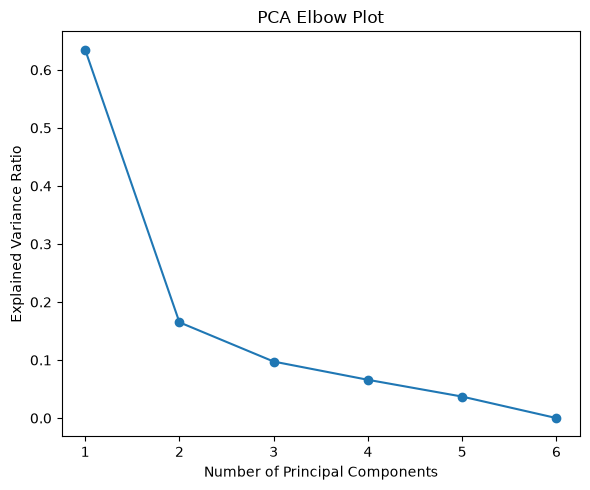

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Z = baseline_latents.detach().cpu().numpy()

max_components = min(
    Z.shape[0],
    Z.shape[1]
)

pca = PCA(
    n_components=max_components
)

pca.fit(Z)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(6, 5))

plt.plot(
    range(1, max_components + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Elbow Plot")
plt.xticks(
    range(1, max_components + 1)
)
plt.tight_layout()
plt.show()

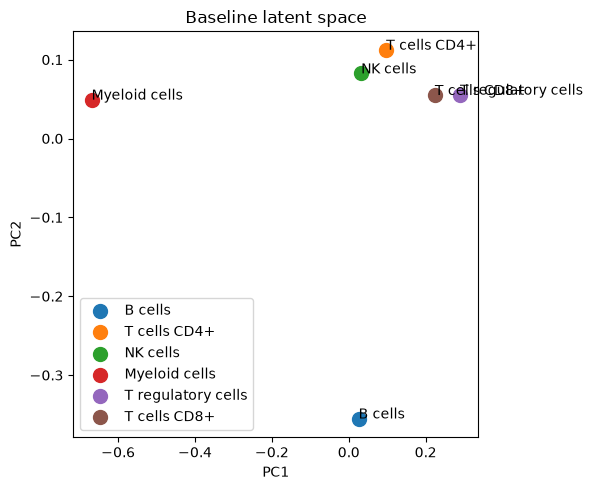

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Z = baseline_latents.detach().cpu().numpy()

pca = PCA(n_components=5)

Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))

for i, ct in enumerate(cell_type_order):
    plt.scatter(
        Z_pca[i, 0],
        Z_pca[i, 1],
        s=100,
        label=ct
    )

    plt.text(
        Z_pca[i, 0],
        Z_pca[i, 1],
        ct
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Baseline latent space")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
latent = baseline_latents.detach().cpu().numpy()

corr_matrix = np.corrcoef(latent)

print(corr_matrix)

[[1.         0.99000541 0.98962864 0.97294765 0.98888506 0.99042301]
 [0.99000541 1.         0.99423556 0.9745831  0.99428261 0.99669376]
 [0.98962864 0.99423556 1.         0.9758082  0.99214863 0.99250532]
 [0.97294765 0.9745831  0.9758082  1.         0.96240341 0.9676762 ]
 [0.98888506 0.99428261 0.99214863 0.96240341 1.         0.99532816]
 [0.99042301 0.99669376 0.99250532 0.9676762  0.99532816 1.        ]]


In [7]:
latent = baseline_latents.detach().cpu().numpy()

latent_corr = np.corrcoef(latent.T)

print(latent_corr.shape)
print(latent_corr)

(128, 128)
[[ 1.         -0.82722379 -0.03894124 ... -0.01340161  0.13120292
  -0.27647303]
 [-0.82722379  1.         -0.27194647 ...  0.52145139 -0.60535143
   0.58166765]
 [-0.03894124 -0.27194647  1.         ... -0.51176112  0.73675444
  -0.54229489]
 ...
 [-0.01340161  0.52145139 -0.51176112 ...  1.         -0.92914072
   0.85674836]
 [ 0.13120292 -0.60535143  0.73675444 ... -0.92914072  1.
  -0.83043861]
 [-0.27647303  0.58166765 -0.54229489 ...  0.85674836 -0.83043861
   1.        ]]


In [8]:
import pandas as pd

baseline_latents_df = pd.DataFrame(
    baseline_latents.detach().cpu().numpy(),
    index=cell_type_order
)

baseline_latents_df.index.name = "cell_type"

baseline_latents_df.columns = [
    f"latent_{i+1}"
    for i in range(baseline_latents_df.shape[1])
]

print(baseline_latents_df)

                    latent_1  latent_2  latent_3  latent_4  latent_5  \
cell_type                                                              
B cells            -0.577453 -0.190523 -0.268494  0.269248  0.245339   
T cells CD4+       -0.667530 -0.141772 -0.261815  0.287594  0.255870   
NK cells           -0.652515 -0.145808 -0.273983  0.226355  0.232210   
Myeloid cells      -0.616884 -0.198747 -0.228541  0.271209  0.332619   
T regulatory cells -0.613406 -0.174482 -0.283958  0.279395  0.236139   
T cells CD8+       -0.639640 -0.139890 -0.250666  0.289837  0.204471   

                    latent_6  latent_7  latent_8  latent_9  latent_10  ...  \
cell_type                                                              ...   
B cells             0.446268  0.248232 -0.390422 -0.130617   0.398918  ...   
T cells CD4+        0.519410  0.279299 -0.433826 -0.197087   0.369449  ...   
NK cells            0.497011  0.265936 -0.415374 -0.178912   0.386031  ...   
Myeloid cells       0.403246  0.3

# Drug latent by MLP

In [9]:
import pandas as pd

de_train = pd.read_parquet(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/de_train.parquet")

In [10]:
de_train = de_train[
    de_train["control"] != True
].copy()

de_train_no_smiles = de_train.drop(
    columns=["sm_lincs_id", "SMILES","control"]
)

Baseline latent: torch.Size([6, 128])
Training cell types: ['T cells CD4+', 'NK cells', 'T regulatory cells', 'T cells CD8+']
X: torch.Size([572, 128])
Drug indices: torch.Size([572])
y: torch.Size([572, 18211])
Number of drugs: 144
Number of genes: 18211
Model device: cuda
Trainable parameters: 10608675
Epoch 10/500 Loss: 2.616813 Best: 2.616813 Patience: 0/30
Epoch 20/500 Loss: 2.267385 Best: 2.267385 Patience: 0/30
Epoch 30/500 Loss: 2.170834 Best: 2.158011 Patience: 1/30
Epoch 40/500 Loss: 2.067085 Best: 2.067085 Patience: 0/30
Epoch 50/500 Loss: 1.834449 Best: 1.834449 Patience: 0/30
Epoch 60/500 Loss: 1.587694 Best: 1.581766 Patience: 3/30
Epoch 70/500 Loss: 1.409047 Best: 1.409047 Patience: 0/30
Epoch 80/500 Loss: 1.368936 Best: 1.303709 Patience: 1/30
Epoch 90/500 Loss: 1.227977 Best: 1.227977 Patience: 0/30
Epoch 100/500 Loss: 1.123561 Best: 1.123561 Patience: 0/30
Epoch 110/500 Loss: 1.088474 Best: 1.078818 Patience: 2/30
Epoch 120/500 Loss: 0.983616 Best: 0.983616 Patience: 

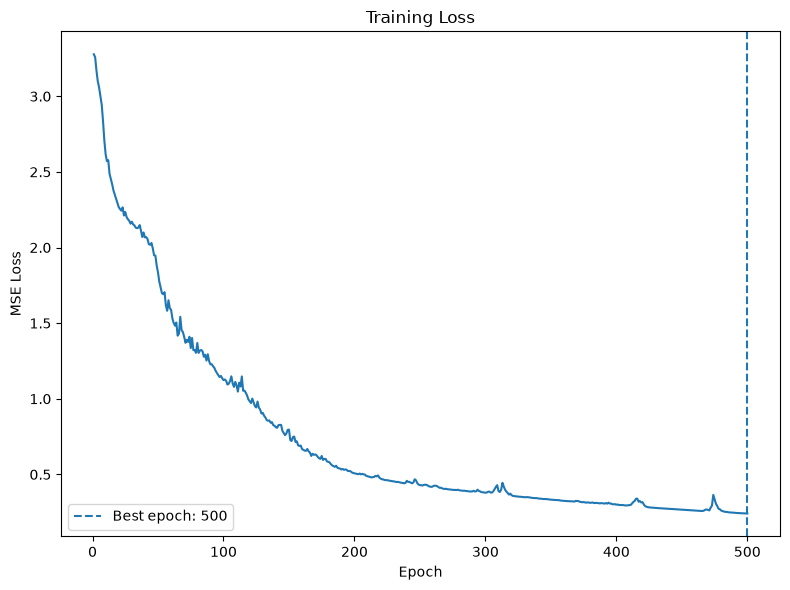

Model saved: /home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/baseline/model


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


training_cell_types = [
    "T cells CD4+",
    "NK cells",
    "T regulatory cells",
    "T cells CD8+"
]


gene_columns = [
    col
    for col in de_train_no_smiles.columns
    if col not in [
        "cell_type",
        "sm_name",
        "control"
    ]
]


cell_type_order = list(
    cell_type_to_indices.keys()
)


baseline_latents_cpu = (
    baseline_latents
    .detach()
    .cpu()
    .float()
)


latent_dict = {
    ct: baseline_latents_cpu[i]
    for i, ct in enumerate(cell_type_order)
}


print(
    "Baseline latent:",
    baseline_latents_cpu.shape
)


print(
    "Training cell types:",
    training_cell_types
)


for ct in training_cell_types:

    if ct not in latent_dict:
        raise ValueError(
            f"{ct} not found in baseline_latents"
        )


drug_names = (
    de_train_no_smiles["sm_name"]
    .drop_duplicates()
    .tolist()
)


drug_to_index = {
    drug: i
    for i, drug in enumerate(drug_names)
}


num_drugs = len(drug_names)


X_list = []
drug_index_list = []
y_list = []
sample_info = []


for _, row in de_train_no_smiles.iterrows():

    ct = row["cell_type"]
    drug = row["sm_name"]

    if ct not in training_cell_types:
        continue

    cell_latent = latent_dict[ct]

    y = torch.tensor(
        row[gene_columns].to_numpy(
            dtype=np.float32
        ),
        dtype=torch.float32
    )

    X_list.append(
        cell_latent
    )

    drug_index_list.append(
        drug_to_index[drug]
    )

    y_list.append(
        y
    )

    sample_info.append(
        {
            "cell_type": ct,
            "sm_name": drug
        }
    )


X = torch.stack(
    X_list
)

drug_indices = torch.tensor(
    drug_index_list,
    dtype=torch.long
)

y = torch.stack(
    y_list
)

sample_info = pd.DataFrame(
    sample_info
)


print(
    "X:",
    X.shape
)

print(
    "Drug indices:",
    drug_indices.shape
)

print(
    "y:",
    y.shape
)

print(
    "Number of drugs:",
    num_drugs
)

print(
    "Number of genes:",
    len(gene_columns)
)


class DrugConditionedDEModel(nn.Module):

    def __init__(
        self,
        latent_input_dim,
        num_drugs,
        drug_embedding_dim,
        output_dim
    ):

        super().__init__()

        self.cell_encoder = nn.Sequential(

            nn.Linear(
                latent_input_dim,
                1024
            ),

            nn.GELU(),

            nn.Linear(
                1024,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                256
            ),

            nn.GELU()
        )

        self.drug_embedding = nn.Embedding(
            num_drugs,
            drug_embedding_dim
        )

        self.de_head = nn.Sequential(

            nn.Linear(
                256 + drug_embedding_dim,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                output_dim
            )
        )


    def forward(
        self,
        cell_latent,
        drug_index
    ):

        cell_hidden = self.cell_encoder(
            cell_latent
        )

        drug_hidden = self.drug_embedding(
            drug_index
        )

        combined = torch.cat(
            [
                cell_hidden,
                drug_hidden
            ],
            dim=1
        )

        output = self.de_head(
            combined
        )

        return output


model = DrugConditionedDEModel(
    latent_input_dim=X.shape[1],
    num_drugs=num_drugs,
    drug_embedding_dim=128,
    output_dim=y.shape[1]
).to(device)


dataset = TensorDataset(
    X,
    drug_indices,
    y
)


loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)


criterion = nn.MSELoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


epochs = 500
early_stopping_patience = 30


print(
    "Model device:",
    device
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


loss_history = []

best_loss = float("inf")
best_epoch = 0
patience_counter = 0

best_state_dict = None


for epoch in range(epochs):

    model.train()

    epoch_loss = 0.0

    for X_batch, drug_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        drug_batch = drug_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction = model(
            X_batch,
            drug_batch
        )

        loss = criterion(
            prediction,
            y_batch
        )

        loss.backward()

        optimizer.step()

        epoch_loss += (
            loss.item()
            * X_batch.size(0)
        )

    epoch_loss /= len(dataset)

    loss_history.append(
        epoch_loss
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss
        best_epoch = epoch + 1
        patience_counter = 0

        best_state_dict = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    else:

        patience_counter += 1


    if (
        epoch + 1
    ) % 10 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"Loss: {epoch_loss:.6f} "
            f"Best: {best_loss:.6f} "
            f"Patience: {patience_counter}/{early_stopping_patience}"
        )


    if patience_counter >= early_stopping_patience:

        print(
            f"Early stopping at epoch {epoch + 1}"
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        print(
            f"Best loss: {best_loss:.6f}"
        )

        break


if best_state_dict is not None:

    model.load_state_dict(
        best_state_dict
    )


model = model.to(device)
model.eval()


with torch.no_grad():

    predictions = []

    for X_batch, drug_batch, _ in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        drug_batch = drug_batch.to(
            device,
            non_blocking=True
        )

        prediction = model(
            X_batch,
            drug_batch
        )

        predictions.append(
            prediction.cpu()
        )


predictions = torch.cat(
    predictions,
    dim=0
)


print(
    "Prediction:",
    predictions.shape
)


print(
    "Best epoch:",
    best_epoch
)

print(
    "Best loss:",
    best_loss
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    range(
        1,
        len(loss_history) + 1
    ),
    loss_history
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Training Loss"
)

plt.legend()

plt.tight_layout()

plt.show()


save_dir = (
    "/home/Data_Drive_8TB/kykim/"
    "7. Kaggle/Single-Cell_Perturbations/"
    "baseline/model"
)


os.makedirs(
    save_dir,
    exist_ok=True
)


torch.save(
    model.state_dict(),
    os.path.join(
        save_dir,
        "drug_conditioned_de_model.pt"
    )
)


torch.save(
    {
        "model_state_dict": model.state_dict(),
        "drug_to_index": drug_to_index,
        "training_cell_types": training_cell_types,
        "gene_columns": gene_columns,
        "loss_history": loss_history,
        "best_epoch": best_epoch,
        "best_loss": best_loss,
        "latent_input_dim": X.shape[1],
        "drug_embedding_dim": 128
    },
    os.path.join(
        save_dir,
        "drug_conditioned_de_checkpoint.pt"
    )
)


np.save(
    os.path.join(
        save_dir,
        "loss_history.npy"
    ),
    np.asarray(
        loss_history,
        dtype=np.float32
    )
)


print(
    "Model saved:",
    save_dir
)

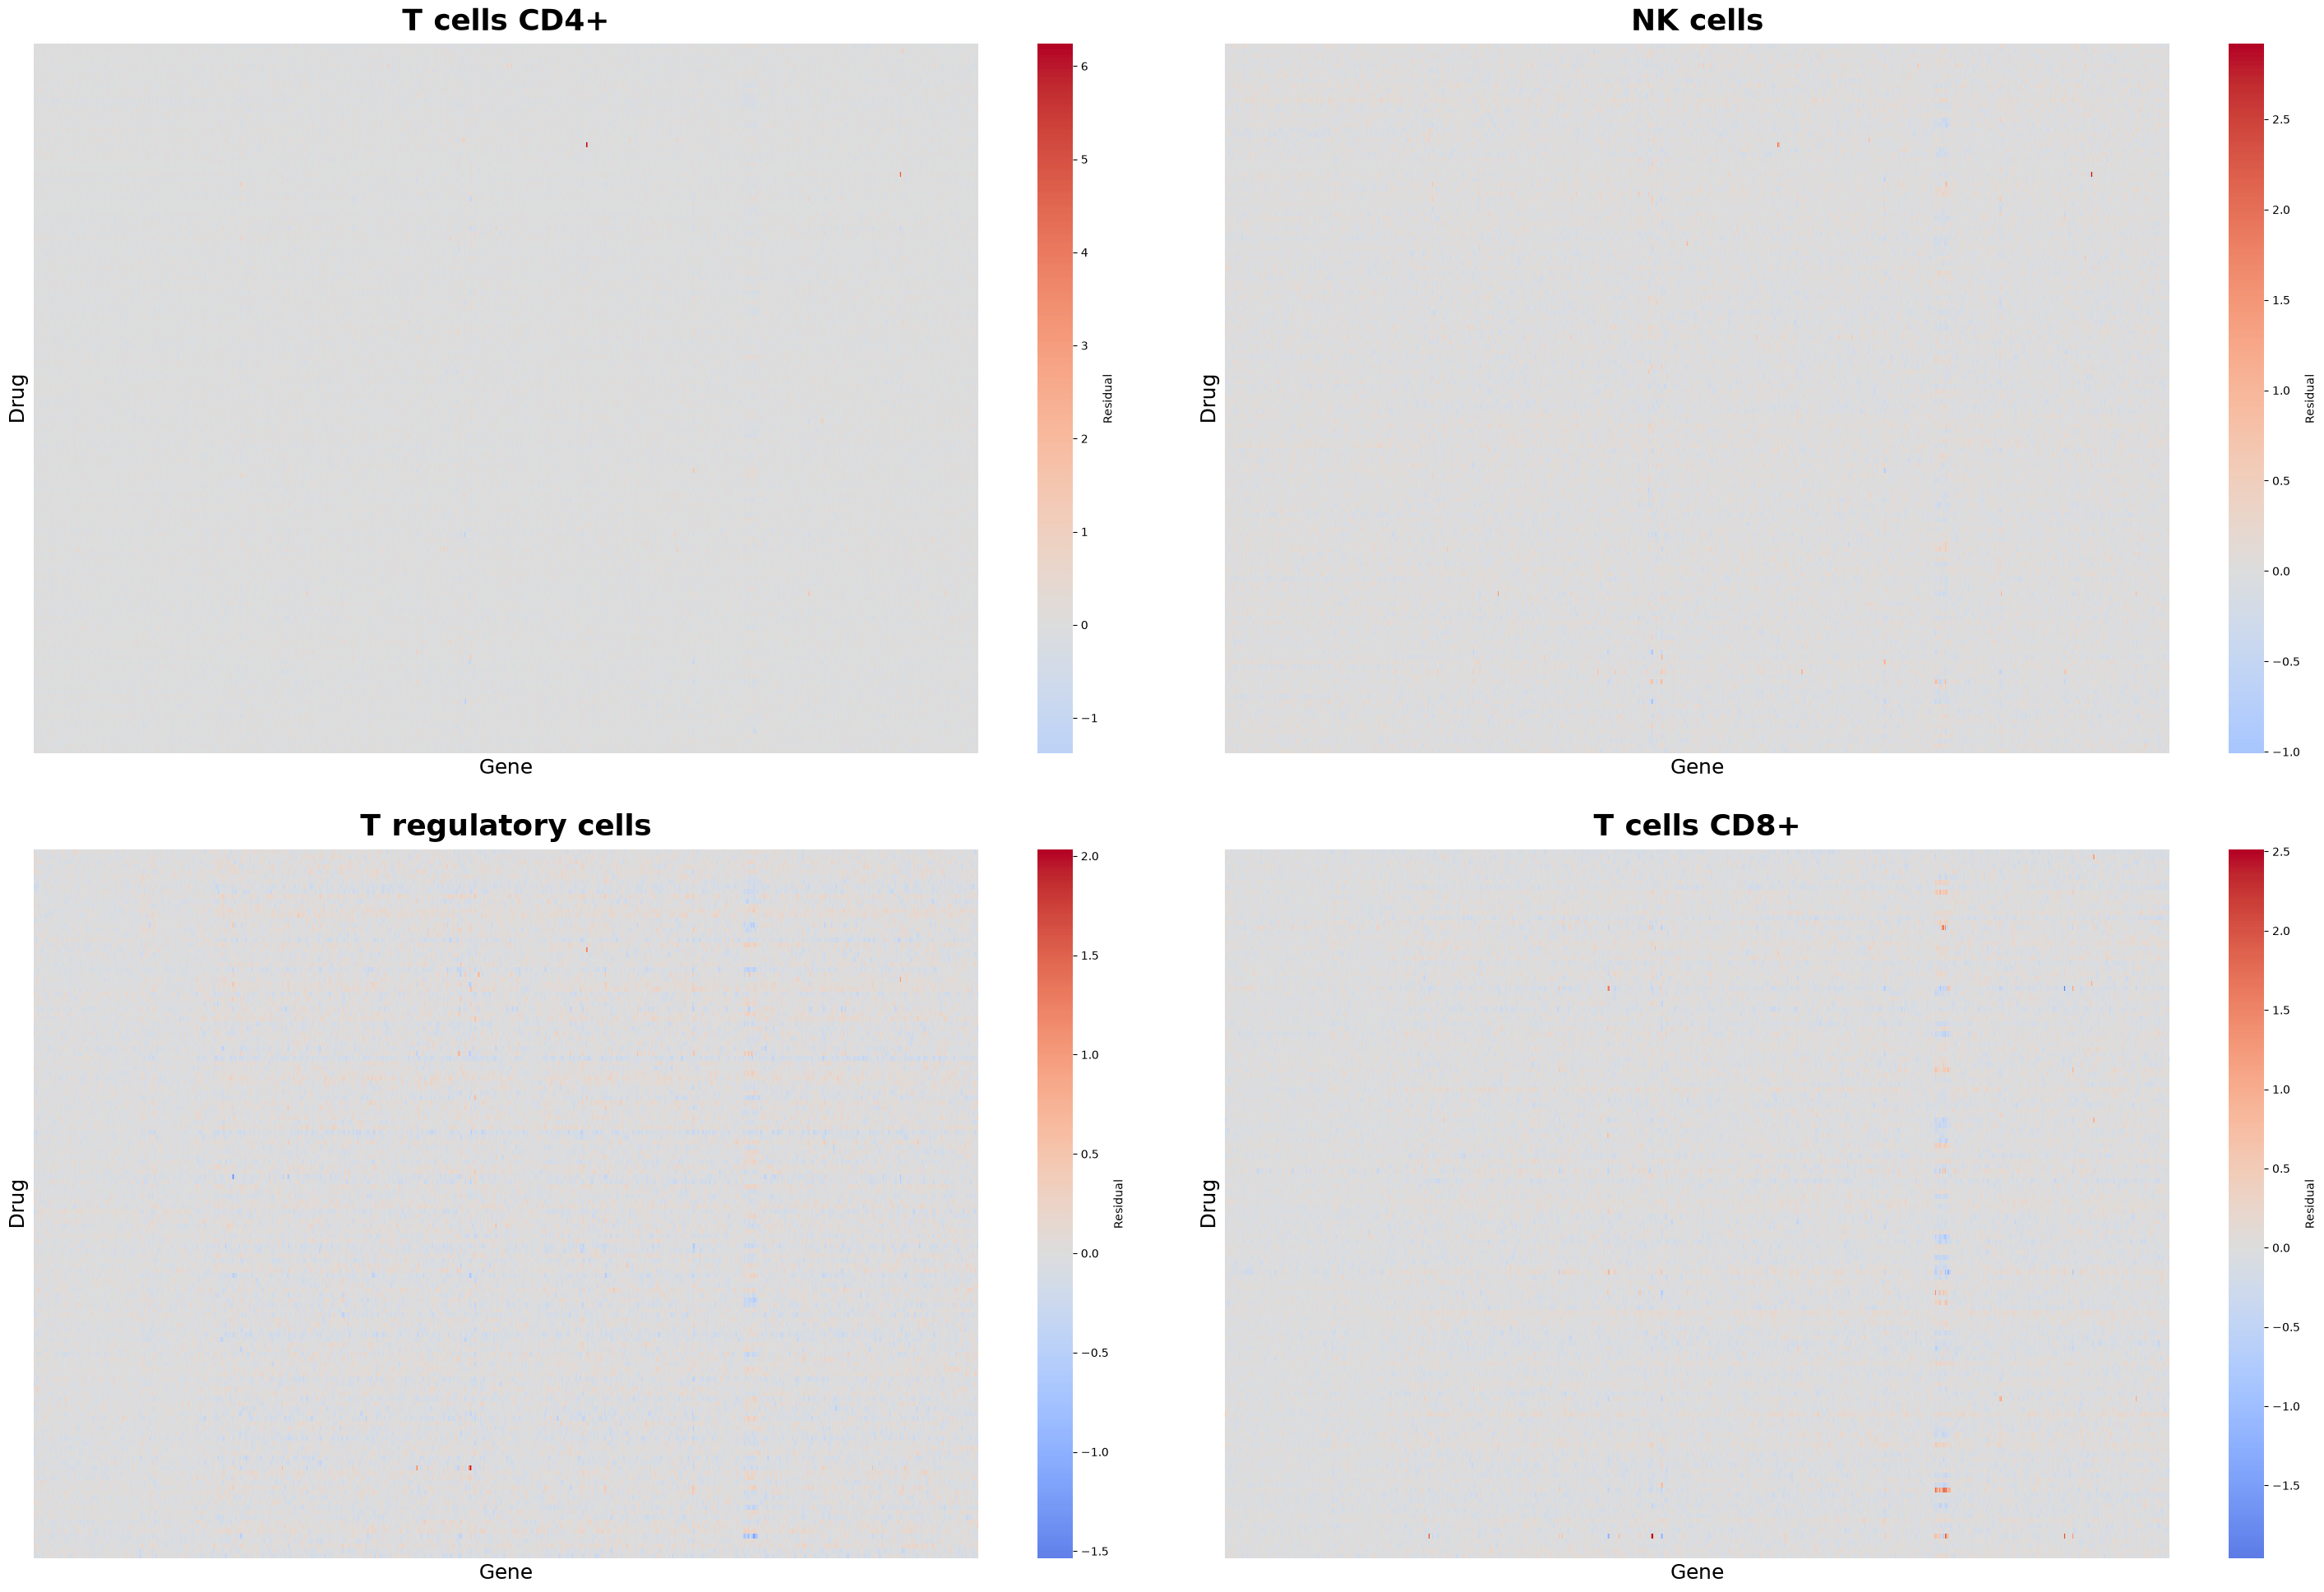

In [12]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns


model.eval()

X_device = X.to(device)
drug_indices_device = drug_indices.to(device)

with torch.no_grad():

    predictions = model(
        X_device,
        drug_indices_device
    ).cpu()

true_values = y.cpu()

residuals = (
    true_values - predictions
).numpy()

residual_df = pd.DataFrame(
    residuals,
    columns=gene_columns
)

residual_df["cell_type"] = sample_info[
    "cell_type"
].values

residual_df["sm_name"] = sample_info[
    "sm_name"
].values


def gaussian_pooling(
    matrix,
    output_size=1000,
    sigma=10.0
):

    n_drugs, n_genes = matrix.shape

    pooled = np.zeros(
        (n_drugs, output_size),
        dtype=np.float32
    )

    source_positions = np.linspace(
        0,
        n_genes - 1,
        n_genes
    )

    target_positions = np.linspace(
        0,
        n_genes - 1,
        output_size
    )

    for i, target in enumerate(
        target_positions
    ):

        distance = (
            source_positions - target
        )

        weights = np.exp(
            -0.5 *
            (distance / sigma) ** 2
        )

        weights /= weights.sum()

        pooled[:, i] = (
            matrix @ weights
        )

    return pooled


fig, axes = plt.subplots(
    2,
    2,
    figsize=(30, 20)
)

axes = axes.flatten()


for ax, ct in zip(
    axes,
    training_cell_types
):

    ct_mask = (
        residual_df["cell_type"] == ct
    )

    heatmap_data = residual_df.loc[
        ct_mask,
        gene_columns
    ].to_numpy(
        dtype=np.float32
    )

    pooled_residual = gaussian_pooling(
        heatmap_data,
        output_size=1000,
        sigma=10.0
    )

    sns.heatmap(
        pooled_residual,
        ax=ax,
        cmap="coolwarm",
        center=0,
        xticklabels=False,
        yticklabels=False,
        cbar=True,
        cbar_kws={
            "label": "Residual"
        }
    )

    ax.set_xlabel(
        "Gene",
        fontsize=18
    )

    ax.set_ylabel(
        "Drug",
        fontsize=18
    )

    ax.set_title(
        ct,
        fontsize=26,
        fontweight="bold",
        pad=12
    )


plt.tight_layout(
    pad=3
)

plt.show()

plt.close()

# Final tunning (Myeloid, B cells)

In [13]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


target_cell_types = [
    "B cells",
    "Myeloid cells"
]


gene_columns = [
    col
    for col in de_train_no_smiles.columns
    if col not in [
        "cell_type",
        "sm_name",
        "control"
    ]
]


latent_columns = [
    col
    for col in baseline_latents_df.columns
    if str(col).startswith("latent_")
]


if len(latent_columns) == 0:

    latent_columns = [
        col
        for col in baseline_latents_df.columns
        if pd.api.types.is_numeric_dtype(
            baseline_latents_df[col]
        )
    ]


print(
    "Latent dimension:",
    len(latent_columns)
)

print(
    "Number of genes:",
    len(gene_columns)
)


target_df = de_train_no_smiles[
    de_train_no_smiles["cell_type"].isin(
        target_cell_types
    )
].copy()


print(
    "\nFine-tuning data:"
)

print(
    target_df["cell_type"].value_counts()
)


drug_names = list(
    drug_to_index.keys()
)


X_list = []
drug_index_list = []
y_list = []


for _, row in target_df.iterrows():

    ct = row["cell_type"]
    drug = row["sm_name"]

    if ct not in baseline_latents_df.index:
        continue

    if drug not in drug_to_index:
        continue

    latent = torch.tensor(
        baseline_latents_df.loc[
            ct,
            latent_columns
        ].to_numpy(
            dtype=np.float32
        ),
        dtype=torch.float32
    )

    target = torch.tensor(
        row[
            gene_columns
        ].to_numpy(
            dtype=np.float32
        ),
        dtype=torch.float32
    )

    X_list.append(
        latent
    )

    drug_index_list.append(
        drug_to_index[drug]
    )

    y_list.append(
        target
    )


X_ft = torch.stack(
    X_list
)

drug_indices_ft = torch.tensor(
    drug_index_list,
    dtype=torch.long
)

y_ft = torch.stack(
    y_list
)


print(
    "\nFine-tuning tensors:"
)

print(
    "X:",
    X_ft.shape
)

print(
    "Drug:",
    drug_indices_ft.shape
)

print(
    "Y:",
    y_ft.shape
)


class DrugConditionedDEModel(nn.Module):

    def __init__(
        self,
        latent_input_dim,
        num_drugs,
        drug_embedding_dim,
        output_dim
    ):

        super().__init__()

        self.cell_encoder = nn.Sequential(

            nn.Linear(
                latent_input_dim,
                1024
            ),

            nn.GELU(),

            nn.Linear(
                1024,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                256
            ),

            nn.GELU()
        )


        self.drug_embedding = nn.Embedding(
            num_drugs,
            drug_embedding_dim
        )


        self.de_head = nn.Sequential(

            nn.Linear(
                256 + drug_embedding_dim,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                512
            ),

            nn.GELU(),

            nn.Linear(
                512,
                output_dim
            )
        )


    def forward(
        self,
        cell_latent,
        drug_index
    ):

        cell_hidden = self.cell_encoder(
            cell_latent
        )

        drug_hidden = self.drug_embedding(
            drug_index
        )

        combined = torch.cat(
            [
                cell_hidden,
                drug_hidden
            ],
            dim=1
        )

        return self.de_head(
            combined
        )


model_ft = DrugConditionedDEModel(
    latent_input_dim=len(latent_columns),
    num_drugs=len(drug_names),
    drug_embedding_dim=128,
    output_dim=len(gene_columns)
).to(device)


checkpoint_path = (
    "/home/Data_Drive_8TB/kykim/"
    "7. Kaggle/Single-Cell_Perturbations/"
    "baseline/model/"
    "drug_conditioned_de_checkpoint.pt"
)


checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


model_ft.load_state_dict(
    checkpoint["model_state_dict"]
)


print(
    "\nPretrained model loaded."
)


for param in model_ft.cell_encoder.parameters():
    param.requires_grad = False


for param in model_ft.drug_embedding.parameters():
    param.requires_grad = True


for param in model_ft.de_head.parameters():
    param.requires_grad = True


trainable_parameters = sum(
    p.numel()
    for p in model_ft.parameters()
    if p.requires_grad
)


total_parameters = sum(
    p.numel()
    for p in model_ft.parameters()
)


print(
    "Trainable parameters:",
    trainable_parameters
)

print(
    "Total parameters:",
    total_parameters
)


dataset_ft = TensorDataset(
    X_ft,
    drug_indices_ft,
    y_ft
)


loader_ft = DataLoader(
    dataset_ft,
    batch_size=8,
    shuffle=True,
    drop_last=False
)


criterion = nn.MSELoss()


optimizer = torch.optim.AdamW(
    [
        {
            "params": model_ft.drug_embedding.parameters(),
            "lr": 1e-5
        },
        {
            "params": model_ft.de_head.parameters(),
            "lr": 1e-5
        }
    ],
    weight_decay=1e-5
)


epochs = 500


loss_history = []


best_loss = float("inf")

best_state = None

patience = 30

patience_counter = 0


print(
    "\nFine-tuning started."
)


for epoch in range(epochs):

    model_ft.train()

    epoch_loss = 0.0


    for X_batch, drug_batch, y_batch in loader_ft:

        X_batch = X_batch.to(
            device
        )

        drug_batch = drug_batch.to(
            device
        )

        y_batch = y_batch.to(
            device
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        prediction = model_ft(
            X_batch,
            drug_batch
        )


        loss = criterion(
            prediction,
            y_batch
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model_ft.parameters(),
            max_norm=1.0
        )


        optimizer.step()


        epoch_loss += (
            loss.item()
            * X_batch.size(0)
        )


    epoch_loss /= len(dataset_ft)

    loss_history.append(
        epoch_loss
    )


    if epoch_loss < best_loss:

        best_loss = epoch_loss

        best_state = copy.deepcopy(
            model_ft.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1


    if (
        epoch + 1
    ) % 10 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"Loss: {epoch_loss:.6f} "
            f"Best: {best_loss:.6f} "
            f"Patience: "
            f"{patience_counter}/{patience}"
        )


    if patience_counter >= patience:

        print(
            f"\nEarly stopping at "
            f"epoch {epoch + 1}"
        )

        break


model_ft.load_state_dict(
    best_state
)


print(
    "\nBest fine-tuning loss:",
    best_loss
)

Latent dimension: 128
Number of genes: 18211

Fine-tuning data:
cell_type
B cells          15
Myeloid cells    15
Name: count, dtype: int64

Fine-tuning tensors:
X: torch.Size([30, 128])
Drug: torch.Size([30])
Y: torch.Size([30, 18211])

Pretrained model loaded.
Trainable parameters: 9820451
Total parameters: 10608675

Fine-tuning started.
Epoch 10/500 Loss: 13.085002 Best: 13.085002 Patience: 0/30
Epoch 20/500 Loss: 11.473362 Best: 11.473362 Patience: 0/30
Epoch 30/500 Loss: 10.031697 Best: 10.031697 Patience: 0/30
Epoch 40/500 Loss: 8.799559 Best: 8.799559 Patience: 0/30
Epoch 50/500 Loss: 7.690742 Best: 7.690742 Patience: 0/30
Epoch 60/500 Loss: 6.690604 Best: 6.690604 Patience: 0/30
Epoch 70/500 Loss: 5.890648 Best: 5.890648 Patience: 0/30
Epoch 80/500 Loss: 5.199797 Best: 5.199797 Patience: 0/30
Epoch 90/500 Loss: 4.574682 Best: 4.574682 Patience: 0/30
Epoch 100/500 Loss: 4.053551 Best: 4.053551 Patience: 0/30
Epoch 110/500 Loss: 3.641745 Best: 3.641745 Patience: 0/30
Epoch 120/50

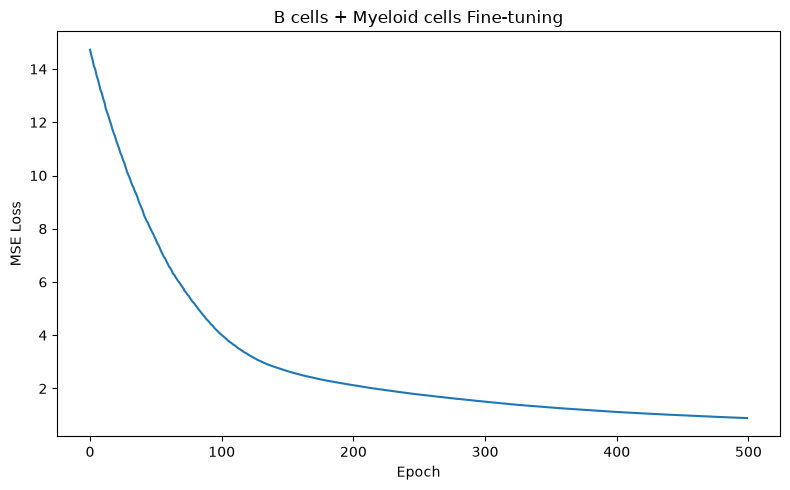

In [14]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    loss_history
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "B cells + Myeloid cells Fine-tuning"
)

plt.tight_layout()

plt.show()

In [15]:
model_ft.eval()


prediction_rows = []


for ct in target_cell_types:

    cell_latent = torch.tensor(
        baseline_latents_df.loc[
            ct,
            latent_columns
        ].to_numpy(
            dtype=np.float32
        ),
        dtype=torch.float32
    )


    for drug in drug_names:

        drug_index = torch.tensor(
            [drug_to_index[drug]],
            dtype=torch.long
        )


        with torch.no_grad():

            prediction = model_ft(
                cell_latent.unsqueeze(0).to(device),
                drug_index.to(device)
            )


        prediction = (
            prediction
            .squeeze(0)
            .cpu()
            .numpy()
        )


        row = {
            "cell_type": ct,
            "sm_name": drug
        }


        row.update(
            {
                gene: value
                for gene, value in zip(
                    gene_columns,
                    prediction
                )
            }
        )


        prediction_rows.append(
            row
        )


predicted_de_finetuned_df = pd.DataFrame(
    prediction_rows,
    columns=[
        "cell_type",
        "sm_name"
    ] + gene_columns
)


print(
    "Fine-tuned prediction shape:",
    predicted_de_finetuned_df.shape
)


print(
    predicted_de_finetuned_df[
        [
            "cell_type",
            "sm_name"
        ] + gene_columns[:5]
    ].head()
)

Fine-tuned prediction shape: (288, 18213)
  cell_type             sm_name      A1BG  A1BG-AS1       A2M   A2M-AS1  \
0   B cells        Clotrimazole  1.304368  0.022456  0.486587  1.067998   
1   B cells  Mometasone Furoate  2.701880  1.045892  2.946593  2.405879   
2   B cells          Idelalisib  0.186646 -0.211842  0.708981  0.225644   
3   B cells          Vandetanib  0.191393 -0.083935  0.605619 -0.121157   
4   B cells           Bosutinib  0.109072 -0.254142  1.074051  0.421915   

      A2MP1  
0  2.395727  
1  5.209074  
2  0.360123  
3  0.137482  
4  1.237206  


# Final submission

In [16]:
import pandas as pd

sample_submission = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/submission/sample_submission.csv"
)

In [17]:
sample_submission

,id,A1BG,A1BG-AS1,A2M,A2M-AS1,A2MP1,A4GALT,AAAS,AACS,AAGAB,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
251,251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
252,252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
253,253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
missing_columns = [
    col
    for col in predicted_de_finetuned_df.columns
    if col not in sample_submission.columns
]

print(missing_columns)

['cell_type', 'sm_name']


In [19]:
id_map = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/submission/id_map.csv"
)

In [20]:
id_map

,id,cell_type,sm_name
0,0,B cells,5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-...
1,1,B cells,ABT-199 (GDC-0199)
2,2,B cells,ABT737
3,3,B cells,AMD-070 (hydrochloride)
4,4,B cells,AT 7867
...,...,...,...
250,250,Myeloid cells,Vandetanib
251,251,Myeloid cells,Vanoxerine
252,252,Myeloid cells,Vardenafil
253,253,Myeloid cells,Vorinostat


In [21]:
import numpy as np
import pandas as pd

id_col = "id"

gene_columns_submission = [
    col
    for col in sample_submission.columns
    if col != id_col
]

print("1. Checking gene columns...")

missing_genes = [
    gene
    for gene in gene_columns_submission
    if gene not in predicted_de_finetuned_df.columns
]

print(
    f"Submission genes: {len(gene_columns_submission)}"
)

print(
    f"Missing genes: {len(missing_genes)}"
)

if missing_genes:
    print(missing_genes[:20])
    raise ValueError("Missing genes detected")


print("2. Preparing prediction table...")

prediction_table = predicted_de_finetuned_df[
    ["cell_type", "sm_name"] + gene_columns_submission
].copy()

print(
    f"Prediction rows: {len(prediction_table)}"
)


print("3. Matching id_map with predictions...")

output = (
    id_map[
        ["id", "cell_type", "sm_name"]
    ]
    .merge(
        prediction_table,
        on=["cell_type", "sm_name"],
        how="left",
        validate="one_to_one"
    )
)

print(
    f"Matched rows: {len(output)}"
)


print("4. Checking prediction values...")

nan_count = (
    output[
        gene_columns_submission
    ]
    .isna()
    .sum()
    .sum()
)

inf_count = np.isinf(
    output[
        gene_columns_submission
    ].to_numpy(
        dtype=np.float64
    )
).sum()

print(
    f"NaN values: {nan_count}"
)

print(
    f"Inf values: {inf_count}"
)


if nan_count > 0:
    raise ValueError(
        f"{nan_count} NaN values found"
    )

if inf_count > 0:
    raise ValueError(
        f"{inf_count} Inf values found"
    )


print("5. Reordering columns...")

output = output[
    ["id"] + gene_columns_submission
]


print(
    f"Final output shape: {output.shape}"
)

print(
    "6. Checking ID order..."
)

if output["id"].equals(
    sample_submission["id"]
):

    print(
        "ID order: OK"
    )

else:

    raise ValueError(
        "ID order does not match sample_submission"
    )


print(
    "7. Submission generation complete."
)

1. Checking gene columns...
Submission genes: 18211
Missing genes: 0
2. Preparing prediction table...
Prediction rows: 288
3. Matching id_map with predictions...
Matched rows: 255
4. Checking prediction values...
NaN values: 0
Inf values: 0
5. Reordering columns...
Final output shape: (255, 18212)
6. Checking ID order...
ID order: OK
7. Submission generation complete.


In [22]:
save_dir = "/home/Data_Drive_8TB/kykim/7. Kaggle/Single-Cell_Perturbations/submission/final"

os.makedirs(save_dir, exist_ok=True)

output_path = os.path.join(
    save_dir,
    "submission.csv"
)

output.to_csv(
    output_path,
    index=False
)

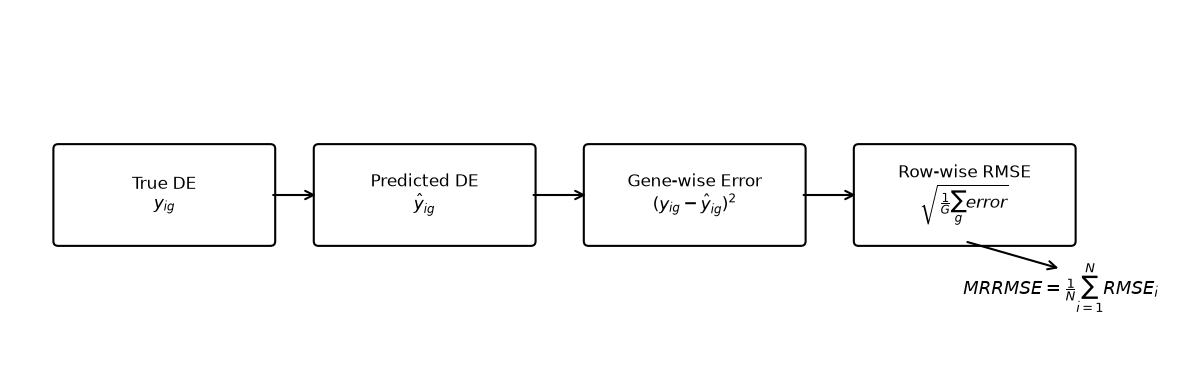

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.5, 1.5, 2.2, 1.0, "True DE\n$y_{ig}$"),
    (3.2, 1.5, 2.2, 1.0, "Predicted DE\n$\\hat{y}_{ig}$"),
    (6.0, 1.5, 2.2, 1.0, "Gene-wise Error\n$(y_{ig}-\\hat{y}_{ig})^2$"),
    (8.8, 1.5, 2.2, 1.0, "Row-wise RMSE\n$\\sqrt{\\frac{1}{G}\\sum_g error}$"),
]

for x, y, w, h, text in boxes:
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.05",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=12
    )

for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + boxes[i][2]
    x2 = boxes[i + 1][0]
    y = boxes[i][1] + boxes[i][3] / 2

    ax.add_patch(
        FancyArrowPatch(
            (x1, y),
            (x2, y),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

ax.text(
    10.9,
    1.0,
    r"$MRRMSE=\frac{1}{N}\sum_{i=1}^{N}RMSE_i$",
    ha="center",
    va="center",
    fontsize=13
)

ax.add_patch(
    FancyArrowPatch(
        (9.9, 1.5),
        (10.9, 1.2),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()